# 1. IMPORTS

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay
)

from imblearn.over_sampling import SMOTE


# 2. LOAD DATA

In [2]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset shape:", df.shape)
print(df.head())

Dataset shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

# 3. EDA

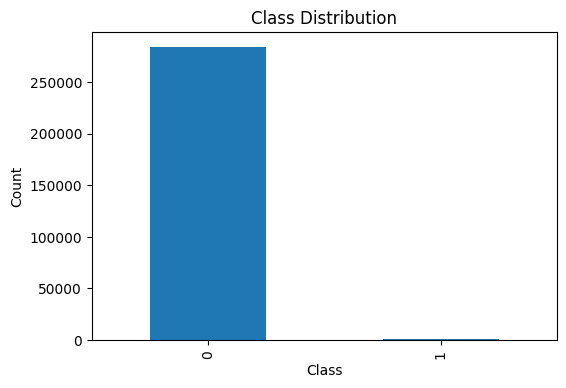

In [3]:

plt.figure(figsize=(6,4))

df['Class'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# 4. SPLIT FEATURES

In [4]:

X = df.drop('Class', axis=1)
y = df['Class']


# 5. TRAIN TEST SPLIT



In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. SCALING (NO LEAKAGE)

In [6]:
scaler = StandardScaler()

X_train[['Amount','Time']] = scaler.fit_transform(
    X_train[['Amount','Time']]
)

X_test[['Amount','Time']] = scaler.transform(
    X_test[['Amount','Time']]
)

# 7. SMOTE

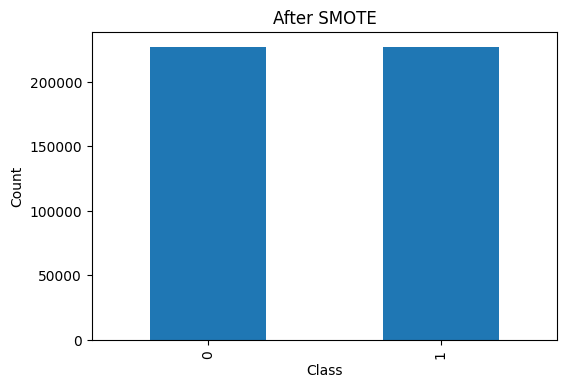

In [7]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train, y_train
)

plt.figure(figsize=(6,4))

pd.Series(y_train_sm).value_counts().plot(kind='bar')

plt.title("After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

# 8. LOGISTIC REGRESSION

In [8]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)

print("LOGISTIC REGRESSION")
print(classification_report(y_test, y_pred_lr))


LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



# 9. RANDOM FOREST

In [9]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_sm, y_train_sm)

y_pred_rf = rf.predict(X_test)

print("===== RANDOM FOREST =====")
print(classification_report(y_test, y_pred_rf))


===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.86      0.84      0.85        98

    accuracy                           1.00     56962
   macro avg       0.93      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



# 10. CONFUSION MATRIX

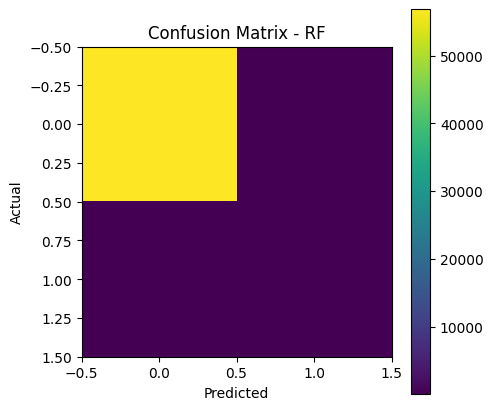

In [10]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,5))

plt.imshow(cm)
plt.colorbar()

plt.title("Confusion Matrix - RF")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


# 11. ROC CURVE

ROC-AUC: 0.975393850562172


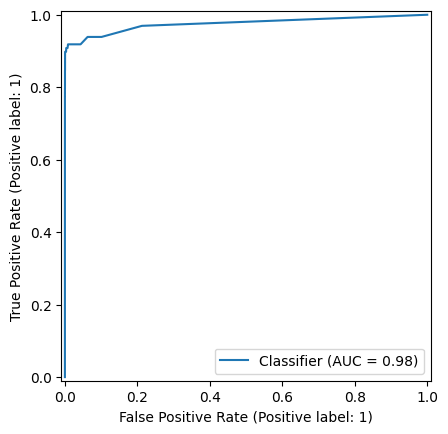

In [11]:
y_prob = rf.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.show()

# 12. FEATURE IMPORTANCE

In [12]:
feat = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 10 Features:")
print(feat.head(10))

Top 10 Features:
V14    0.183715
V10    0.111427
V4     0.107683
V12    0.096535
V17    0.086032
V11    0.062092
V3     0.058436
V16    0.053122
V2     0.031262
V7     0.023408
dtype: float64


# 13. SAVE MODEL

In [13]:
joblib.dump(rf, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved!")

Model and scaler saved!


# 14. THRESHOLD TUNING

In [14]:
y_custom = (y_prob > 0.3).astype(int)

print("===== THRESHOLD 0.3 =====")
print(classification_report(y_test, y_custom))

===== THRESHOLD 0.3 =====
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.74      0.90      0.81        98

    accuracy                           1.00     56962
   macro avg       0.87      0.95      0.91     56962
weighted avg       1.00      1.00      1.00     56962

